In [ ]:
!pip install -q -U optbinning xgboost scikit-learn optuna lightgbm

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from typing import Optional
from optbinning import BinningProcess
import re, gc
import matplotlib.pyplot as plt
from typing import Tuple,Literal
from collections import defaultdict, deque
from itertools import combinations
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/credit_train.csv')
print(df.shape)
display(df.head())

(3000, 15)


,age,income,loan_amount,loan_term,credit_score,num_credit_lines,num_delinquencies,employment_years,debt_to_income,home_ownership,loan_purpose,num_inquiries,savings_balance,months_last_delinq,default
0,59,58822,14317,48,669,13,0,0.2,0.122,MORTGAGE,MEDICAL,2,9438.0,NaN,0
1,49,21461,9006,60,612,8,0,2.8,0.443,MORTGAGE,PERSONAL,1,6223.0,NaN,0
2,35,75417,12004,36,724,13,3,8.3,0.152,RENT,DEBT_CONSOLIDATION,2,4063.0,22.0,0
3,63,133964,7904,48,555,11,0,5.6,0.302,OWN,AUTO,4,2957.0,NaN,0
4,28,134306,6135,48,672,10,0,0.1,0.438,MORTGAGE,MEDICAL,5,385.0,NaN,0


In [ ]:
df.columns

Index(['age', 'income', 'loan_amount', 'loan_term', 'credit_score',
       'num_credit_lines', 'num_delinquencies', 'employment_years',
       'debt_to_income', 'home_ownership', 'loan_purpose', 'num_inquiries',
       'savings_balance', 'months_last_delinq', 'default'],
      dtype='object')

In [ ]:
# Overall Default Rate
print(f"Overall Default Rate: {df['default'].mean():.2%}")

# Default Rate by Key Categorical Dimensions
print("\n--- Default Rate by Categorical Features ---")
categorical_features = [
    'home_ownership',
    'loan_purpose',
    'has_delinquency_flag',
    'thin_file_flag',
    'high_dti_flag',
    'low_savings_flag',
    'low_score_flag',
    'recent_delinq_flag'
]

for col in categorical_features:
    if col in df.columns:
        print(f"\nDefault Rate by {col}:")
        pivot_table = df.groupby(col)['default'].mean().reset_index()
        pivot_table['default_rate_pct'] = pivot_table['default'].apply(lambda x: f'{x:.2%}')
        display(pivot_table.drop(columns='default'))
    else:
        print(f"Column '{col}' not found in df.")

# Default Rate by Binned Numerical Features using OptimalBinning
print("\n--- Default Rate by Binned Numerical Features ---")
from optbinning import OptimalBinning

def analyze_binned_default_rate(df, feature, target='default', dtype="numerical"):
    if feature not in df.columns:
        print(f"Column '{feature}' not found.")
        return

    # OptimalBinning expects the target to be 0/1, which 'default' already is.
    # Using prebinning_method='cart' for robustness, and reasonable bin limits.
    optb = OptimalBinning(
        name=feature,
        dtype=dtype,
        strategy='chimerge', # A common strategy for optimal binning
        min_n_bins=5,
        max_n_bins=10,
        min_bin_size=0.05, # Ensure each bin has at least 5% of data
        gamma=0 # Gini index for binary target, 0 means no restriction on bin sizes
    )
    try:
        optb.fit(df[feature].fillna(df[feature].median()), df[target]) # Fill NaNs for binning
        binning_table = optb.binning_table.build()
        print(f"\nDefault Rate by Binned {feature}:")
        display(binning_table[['Bin', 'Count', 'Count (%)', 'Event Rate', 'Event Rate (%)']])
        # Optional: Plot the binning table
        # optb.binning_table.plot(metric='event_rate')
        # plt.title(f'Event Rate by Binned {feature}')
        # plt.show()
    except Exception as e:
        print(f"Could not fit OptimalBinning for {feature}: {e}")
        # If error occurs, fallback to simple quantile binning if possible
        if dtype == "numerical":
            print(f"Attempting simple quantile binning for {feature}...")
            df_temp = df[[feature, target]].copy().dropna()
            if not df_temp.empty:
                df_temp['binned_feature'] = pd.qcut(df_temp[feature], q=5, duplicates='drop')
                simple_bin_dr = df_temp.groupby('binned_feature')[target].mean().reset_index()
                simple_bin_dr['default_rate_pct'] = simple_bin_dr[target].apply(lambda x: f'{x:.2%}')
                display(simple_bin_dr.drop(columns=target))
            else:
                print(f"Not enough data for simple binning of {feature}.")

# Analyze some original numerical features (filled versions from feat_df)
analyze_binned_default_rate(df, 'age_f', dtype='numerical')
analyze_binned_default_rate(df, 'income_f', dtype='numerical')
analyze_binned_default_rate(df, 'credit_score_f', dtype='numerical')
analyze_binned_default_rate(df, 'employment_years_f', dtype='numerical')


Overall Default Rate: 14.20%

--- Default Rate by Categorical Features ---

Default Rate by home_ownership:


,home_ownership,default_rate_pct
0,MORTGAGE,13.73%
1,OWN,12.17%
2,RENT,15.95%



Default Rate by loan_purpose:


,loan_purpose,default_rate_pct
0,AUTO,13.02%
1,DEBT_CONSOLIDATION,12.97%
2,HOME_IMPROVEMENT,17.72%
3,MEDICAL,15.02%
4,PERSONAL,14.25%


Column 'has_delinquency_flag' not found in df.
Column 'thin_file_flag' not found in df.
Column 'high_dti_flag' not found in df.
Column 'low_savings_flag' not found in df.
Column 'low_score_flag' not found in df.
Column 'recent_delinq_flag' not found in df.

--- Default Rate by Binned Numerical Features ---
Column 'age_f' not found.
Column 'income_f' not found.
Column 'credit_score_f' not found.
Column 'employment_years_f' not found.


In [ ]:
def inspect_raw(df):
    print(f"Shape: {df.shape}\n")

    # -------------------------
    # 1. Missing
    # -------------------------
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    print("[1] Missing values")
    print(miss.to_frame('missing').assign(pct=lambda x: (x['missing']/len(df)*100).round(2)) if len(miss) else "  None")

    # -------------------------
    # 2. Duplicates
    # -------------------------
    print(f"\n[2] Duplicate rows : {df.duplicated().sum()}")

    # -------------------------
    # 3. Categorical — unique values & suspicious entries
    # -------------------------
    cat_cols = ['home_ownership', 'loan_purpose']
    print("\n[3] Categorical value counts")
    for c in cat_cols:
        if c in df.columns:
            print(f"\n  {c}:")
            print(df[c].str.strip().str.lower().value_counts(dropna=False).to_string())

    # -------------------------
    # 4. Numeric sanity — negatives & zeros
    # -------------------------
    should_be_positive = [
        'age', 'income', 'loan_amount', 'loan_term', 'credit_score',
        'num_credit_lines', 'num_delinquencies', 'employment_years',
        'num_inquiries', 'savings_balance', 'months_last_delinq'
    ]
    print("\n[4] Negative / zero values in numeric cols")
    for c in should_be_positive:
        if c in df.columns:
            n_neg  = (df[c] < 0).sum()
            n_zero = (df[c] == 0).sum()
            if n_neg > 0 or n_zero > 0:
                print(f"  {c}: negatives={n_neg}, zeros={n_zero}")

    # -------------------------
    # 5. Credit score range (should be 300–850)
    # -------------------------
    if 'credit_score' in df.columns:
        out_range = ((df['credit_score'] < 300) | (df['credit_score'] > 850)).sum()
        print(f"\n[5] Credit score out of range (300-850) : {out_range}")
        print(f"    min={df['credit_score'].min()}, max={df['credit_score'].max()}")

    # -------------------------
    # 6. DTI sanity (should be 0–1 or 0–100)
    # -------------------------
    if 'debt_to_income' in df.columns:
        print(f"\n[6] DTI range")
        print(f"    min={df['debt_to_income'].min():.4f}, max={df['debt_to_income'].max():.4f}")
        print(f"    > 1.0 : {(df['debt_to_income'] > 1.0).sum()} rows")
        print(f"    > 100 : {(df['debt_to_income'] > 100).sum()} rows")

    # -------------------------
    # 7. Loan term — sensible values?
    # -------------------------
    if 'loan_term' in df.columns:
        print(f"\n[7] Loan term unique values")
        print(f"    {sorted(df['loan_term'].dropna().unique())}")

    # -------------------------
    # 8. Employment vs age (already found issues here)
    # -------------------------
    if 'employment_years' in df.columns and 'age' in df.columns:
        mask = df['employment_years'] > (df['age'] - 18)
        print(f"\n[8] Employment before age 18 : {mask.sum()} rows")

    # -------------------------
    # 9. Target
    # -------------------------
    if 'default' in df.columns:
        print(f"\n[9] Target — default rate : {df['default'].mean():.2%}")
        print(df['default'].value_counts())

    # -------------------------
    # 10. Numeric summary
    # -------------------------
    print("\n[10] Numeric summary")
    print(df.describe().round(2).to_string())


In [ ]:
inspect_raw(df)

Shape: (2829, 15)

[1] Missing values
                    missing    pct
months_last_delinq     1418  50.12
savings_balance         140   4.95
employment_years        133   4.70

[2] Duplicate rows : 0

[3] Categorical value counts

  home_ownership:
home_ownership
mortgage    1301
rent         978
own          550

  loan_purpose:
loan_purpose
debt_consolidation    971
personal              697
auto                  433
home_improvement      415
medical               313

[4] Negative / zero values in numeric cols
  num_delinquencies: negatives=0, zeros=1418
  employment_years: negatives=0, zeros=26
  num_inquiries: negatives=0, zeros=961

[5] Credit score out of range (300-850) : 0
    min=370, max=850

[6] DTI range
    min=0.0100, max=0.7510
    > 1.0 : 0 rows
    > 100 : 0 rows

[7] Loan term unique values
    [np.int64(12), np.int64(24), np.int64(36), np.int64(48), np.int64(60)]

[8] Employment before age 18 : 0 rows

[9] Target — default rate : 14.25%
default
0    2426
1     403

In [ ]:
# 1. months_last_delinq — 50% missing, but num_delinquencies == 0 for same rows
#    missing = never delinquent, NOT random missing — already handled by never_delinquent flag ✅

# 2. num_delinquencies zeros = 1418 matches months_last_delinq missing = 1418 exactly
#    Confirm they're the same rows
print("zeros in delinq match missing in months_last_delinq:")
print((df['num_delinquencies'] == 0).sum(), df['months_last_delinq'].isna().sum())
mask_check = (df['num_delinquencies'] == 0) & (df['months_last_delinq'].isna())
print(f"Overlap : {mask_check.sum()}")  # should be ~1418

# 3. savings_balance — max=350,058 vs mean=8,366, std=17,018
#    Extreme right skew — 18 outliers flagged earlier, winsorise in feature eng ✅ already handled

# 4. income — max=346,728 vs mean=59,613
#    Same issue — already winsorised ✅

# 5. employment_years — 26 zeros (unemployed? or data entry?)
print("\nemployment_years == 0 profiles:")
print(df[df['employment_years'] == 0][['age', 'income', 'loan_purpose', 'default']].describe())

# 6. savings_balance — 140 missing (4.95%), NOT at random likely
#    Check if missingness correlates with default
print("\nDefault rate by savings_balance missingness:")
print(df.groupby(df['savings_balance'].isna())['default'].mean())

# 7. employment_years — 133 missing (4.70%)
#    Same check
print("\nDefault rate by employment_years missingness:")
print(df.groupby(df['employment_years'].isna())['default'].mean())

# 8. Class imbalance — 14.25% default rate
#    Not severe but worth noting for model — may need class_weight='balanced'
print(f"\nClass ratio 0:1 = {2426/403:.1f}:1")

zeros in delinq match missing in months_last_delinq:
1418 1418
Overlap : 1418

employment_years == 0 profiles:
             age         income    default
count  26.000000      26.000000  26.000000
mean   43.192308   51353.692308   0.192308
std    12.846849   21170.278108   0.401918
min    21.000000   14201.000000   0.000000
25%    32.750000   38767.500000   0.000000
50%    42.000000   50130.000000   0.000000
75%    51.750000   59619.750000   0.000000
max    68.000000  105407.000000   1.000000

Default rate by savings_balance missingness:
savings_balance
False    0.144292
True     0.107143
Name: default, dtype: float64

Default rate by employment_years missingness:
employment_years
False    0.145030
True     0.090226
Name: default, dtype: float64

Class ratio 0:1 = 6.0:1


In [ ]:
# employment_years vs age sanity check
emp_age = df[['age', 'employment_years']].copy()

print("[1] Basic stats")
print(emp_age.describe().round(2))

print("\n[2] Impossible: employment_years >= age")
mask1 = df['employment_years'] >= df['age']
print(f"    {mask1.sum()} rows")
print(df.loc[mask1, ['age', 'employment_years']].head(20))

print("\n[3] Suspicious: employment_years > age - 18")
mask2 = df['employment_years'] > (df['age'] - 18)
print(f"    {mask2.sum()} rows")
print(df.loc[mask2, ['age', 'employment_years']].describe().round(2))

print("\n[4] employment_years > 40 (extreme tenure)")
mask3 = df['employment_years'] > 40
print(f"    {mask3.sum()} rows")
print(df.loc[mask3, ['age', 'employment_years']])

print("\n[5] employment_years == 0")
mask4 = df['employment_years'] == 0
print(f"    {mask4.sum()} rows ({mask4.sum()/len(df)*100:.2f}%)")

print("\n[6] Distribution of employment_to_age ratio")
ratio = df['employment_years'] / (df['age'] + 1e-6)
print(ratio.describe().round(4))
print(f"\n    ratio > 0.9 (employed for >90% of life): {(ratio > 0.9).sum()} rows")
print(f"    ratio > 1.0 (impossible):                 {(ratio > 1.0).sum()} rows")

[1] Basic stats
           age  employment_years
count  2829.00           2696.00
mean     46.29              4.50
std      13.53              4.45
min      21.00              0.00
25%      35.00              1.30
50%      46.00              3.10
75%      57.00              6.20
max      69.00             38.20

[2] Impossible: employment_years >= age
    0 rows
Empty DataFrame
Columns: [age, employment_years]
Index: []

[3] Suspicious: employment_years > age - 18
    0 rows
       age  employment_years
count  0.0               0.0
mean   NaN               NaN
std    NaN               NaN
min    NaN               NaN
25%    NaN               NaN
50%    NaN               NaN
75%    NaN               NaN
max    NaN               NaN

[4] employment_years > 40 (extreme tenure)
    0 rows
Empty DataFrame
Columns: [age, employment_years]
Index: []

[5] employment_years == 0
    26 rows (0.92%)

[6] Distribution of employment_to_age ratio
count    2696.0000
mean        0.1012
std         0.0

In [ ]:
before = len(df)

# Hard impossible — employed longer than alive
mask_impossible = df['employment_years'] >= df['age']

# Suspicious — started working before 18
mask_suspicious = df['employment_years'] > (df['age'] - 18)

drop_mask = mask_impossible | mask_suspicious

df = df[~drop_mask].reset_index(drop=True)

print(f"Dropped — impossible (emp >= age)       : {mask_impossible.sum()}")
print(f"Dropped — suspicious (started before 18): {mask_suspicious.sum()}")
print(f"Dropped total (union)                   : {drop_mask.sum()}")
print(f"Rows before : {before}")
print(f"Rows after  : {len(df)}")

# Verify
ratio = df['employment_years'] / (df['age'] + 1e-6)
print(f"\nMax ratio after clean : {ratio.max():.4f}  (should be < 1.0)")
print(f"Remaining impossible  : {(df['employment_years'] >= df['age']).sum()}")

Dropped — impossible (emp >= age)       : 0
Dropped — suspicious (started before 18): 0
Dropped total (union)                   : 0
Rows before : 2829
Rows after  : 2829

Max ratio after clean : 0.6367  (should be < 1.0)
Remaining impossible  : 0


In [ ]:
def make_raw_credit_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-6

    # -------------------------
    # Numeric cleanup
    # -------------------------
    num_cols = [
        'age', 'income', 'loan_amount', 'loan_term', 'credit_score',
        'num_credit_lines', 'num_delinquencies', 'employment_years',
        'debt_to_income', 'num_inquiries', 'savings_balance',
        'months_last_delinq'
    ]
    for c in num_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')

    # -------------------------
    # Categorical cleanup — normalise before anything
    # -------------------------
    for c in ['home_ownership', 'loan_purpose']:
        if c in out.columns:
            out[c] = out[c].str.strip().str.lower()

    # -------------------------
    # Missing flags BEFORE anything
    # -------------------------
    for c in num_cols:
        if c in out.columns:
            out[f'{c}_missing'] = out[c].isna().astype('int8')

    if 'months_last_delinq' in out.columns:
        out['never_delinquent'] = out['months_last_delinq'].isna().astype('int8')

    # savings_balance missing correlates with default — keep as signal
    if 'savings_balance' in out.columns:
        out['savings_missing'] = out['savings_balance'].isna().astype('int8')

    # employment_years missing — same
    if 'employment_years' in out.columns:
        out['employment_missing'] = out['employment_years'].isna().astype('int8')

    # -------------------------
    # Winsorize inputs FIRST at 1-99
    # -------------------------
    winsor_cols = [
        'income', 'loan_amount', 'savings_balance', 'age',
        'employment_years', 'months_last_delinq', 'credit_score',
        'num_inquiries', 'num_delinquencies', 'num_credit_lines',
        'debt_to_income', 'loan_term'
    ]
    for c in winsor_cols:
        if c in out.columns:
            lo = out[c].quantile(0.01)
            hi = out[c].quantile(0.99)
            out[c] = out[c].clip(lower=lo, upper=hi)

    # -------------------------
    # Stable filled versions for ratio math
    # -------------------------
    _inc  = out['income'].fillna(out['income'].median())
    _loan = out['loan_amount'].fillna(out['loan_amount'].median())
    _sav  = out['savings_balance'].fillna(0)
    _cs   = out['credit_score'].fillna(out['credit_score'].median())
    _dti  = out['debt_to_income'].fillna(out['debt_to_income'].median())
    _deli = out['num_delinquencies'].fillna(0)
    _inq  = out['num_inquiries'].fillna(0)
    _cl   = out['num_credit_lines'].fillna(0)
    _emp  = out['employment_years'].fillna(0)
    _age  = out['age'].fillna(out['age'].median())
    _term = out['loan_term'].fillna(out['loan_term'].median())
    _mld  = out['months_last_delinq'].fillna(999)

    # -------------------------
    # Credit score normalised
    # -------------------------
    _cs_norm = (_cs - 300) / 550
    out['credit_score_norm'] = _cs_norm

    # -------------------------
    # Log transforms
    # -------------------------
    for raw, col in [
        (_inc,  'log1p_income'),
        (_loan, 'log1p_loan_amount'),
        (_sav,  'log1p_savings_balance'),
        (_inq,  'log1p_num_inquiries'),
        (_deli, 'log1p_num_delinquencies'),
        (_mld,  'log1p_months_last_delinq'),
    ]:
        out[col] = np.log1p(np.clip(raw, 0, None))

    # -------------------------
    # Affordability
    # -------------------------
    _pmt = _loan / (_term + 1)
    out['monthly_payment_est']  = _pmt
    out['loan_to_income']       = _loan / (_inc + eps)
    out['payment_to_income']    = _pmt  / (_inc + eps)
    out['residual_income']      = _inc  - _pmt
    out['residual_income_pct']  = (_inc - _pmt) / (_inc + eps)
    out['savings_to_income']    = _sav  / (_inc + eps)
    out['savings_to_loan']      = _sav  / (_loan + eps)
    out['savings_months']       = _sav  / (_pmt + eps)
    out['total_burden']         = _dti  + out['payment_to_income']
    out['debt_service_ratio']   = (_pmt + _dti * _inc) / (_inc + eps)

    # -------------------------
    # Delinquency & inquiry
    # -------------------------
    out['delinq_rate']          = _deli / (_cl + 1)
    out['inquiry_rate']         = _inq  / (_cl + 1)
    out['delinq_recency_score'] = _deli / (_mld + 1)
    out['delinq_x_inquiry']     = _deli * _inq
    out['dti_x_delinq']         = _dti  * _deli
    out['score_per_delinq']     = _cs_norm / (_deli + 1)
    out['score_per_inquiry']    = _cs_norm / (_inq  + 1)

    # -------------------------
    # Employment & stability
    # -------------------------
    out['employment_to_age']    = _emp / (_age + eps)
    out['income_per_emp_year']  = _inc / (_emp + 1)
    out['income_stability']     = _inc * (_emp / (_age + eps))

    # -------------------------
    # NEW: home_ownership encoding + interactions
    # rent = least stable, own = most stable, mortgage = middle
    # -------------------------
    if 'home_ownership' in out.columns:
        # Ordinal stability encoding
        ownership_map = {'rent': 0, 'mortgage': 1, 'own': 2}
        out['home_ownership_ord'] = out['home_ownership'].map(ownership_map).fillna(0).astype('int8')

        # Binary flags
        out['is_renter']          = (out['home_ownership'] == 'rent').astype('int8')
        out['is_owner']           = (out['home_ownership'] == 'own').astype('int8')
        out['is_mortgage']        = (out['home_ownership'] == 'mortgage').astype('int8')

        # Interactions — renter with high loan burden is higher risk
        out['renter_x_lti']       = out['is_renter'] * out['loan_to_income']
        out['renter_x_dti']       = out['is_renter'] * _dti
        out['renter_x_low_sav']   = out['is_renter'] * (_sav <= 1000).astype(int)

        # Owner with mortgage already has housing debt
        out['mortgage_x_burden']  = out['is_mortgage'] * out['total_burden']
        out['mortgage_x_dti']     = out['is_mortgage'] * _dti

        # Stability score boost for owners
        out['stability_score']    = out['home_ownership_ord'] * out['employment_to_age']

    # -------------------------
    # NEW: loan_purpose encoding + interactions
    # debt_consolidation = potentially distressed, auto/home = asset-backed = safer
    # -------------------------
    if 'loan_purpose' in out.columns:
        # Risk-ordered ordinal (lower = riskier)
        purpose_risk_map = {
            'debt_consolidation': 0,   # highest risk — often struggling borrower
            'medical'           : 1,   # emergency, not discretionary
            'personal'          : 2,   # general
            'home_improvement'  : 3,   # asset-backed benefit
            'auto'              : 4,   # asset-backed
        }
        out['loan_purpose_risk'] = out['loan_purpose'].map(purpose_risk_map).fillna(2).astype('int8')

        # Binary flags for key purposes
        out['is_debt_consolidation'] = (out['loan_purpose'] == 'debt_consolidation').astype('int8')
        out['is_medical']            = (out['loan_purpose'] == 'medical').astype('int8')
        out['is_asset_backed']       = (out['loan_purpose'].isin(['auto', 'home_improvement'])).astype('int8')

        # Debt consolidation + already bad profile = very high risk
        out['debtcon_x_delinq']      = out['is_debt_consolidation'] * _deli
        out['debtcon_x_dti']         = out['is_debt_consolidation'] * _dti
        out['debtcon_x_low_score']   = out['is_debt_consolidation'] * (1 - _cs_norm)

        # Medical loan + low savings = unable to absorb shock
        out['medical_x_no_savings']  = out['is_medical'] * (_sav <= 1000).astype(int)

    # -------------------------
    # Composite risk index
    # -------------------------
    out['composite_risk'] = (
        (1 - _cs_norm)                               * 0.25 +
        out['loan_to_income']    .clip(0, 5) / 5     * 0.20 +
        out['total_burden']      .clip(0, 2) / 2     * 0.15 +
        out['delinq_rate']       .clip(0, 1)          * 0.15 +
        out['inquiry_rate']      .clip(0, 1)          * 0.10 +
        (1 - out['savings_months'].clip(0, 12) / 12) * 0.10 +
        out['is_renter']                              * 0.05   # housing instability
        if 'is_renter' in out.columns else 0
    )

    # -------------------------
    # Segmented interactions
    # -------------------------
    out['risk_score_x_burden']  = (1 - _cs_norm) * out['total_burden'].clip(0, 2)
    out['delinq_x_lti']         = _deli * out['loan_to_income'].clip(0, 5)
    out['low_sav_x_pti']        = (1 - out['savings_months'].clip(0, 12) / 12) * out['payment_to_income'].clip(0, 1)
    out['young_thin_file']      = (1 / (_age + 1)) * (1 / (_cl + 1))
    out['desperate_borrowing']  = np.log1p(_inq) * np.log1p(_deli)
    out['emp_years_per_loan_k'] = _emp / (_loan / 1000 + 1)
    out['sav_x_emp_stability']  = _sav * (_emp / (_age + eps))

    # -------------------------
    # Binary flags
    # -------------------------
    out['has_delinquency']     = (_deli > 0).astype('int8')
    out['many_inquiries']      = (_inq  >= 3).astype('int8')
    out['thin_file']           = (_cl   <= 1).astype('int8')
    out['high_dti']            = (_dti  > 0.4).astype('int8')
    out['low_savings']         = (_sav  <= 1000).astype('int8')
    out['low_score']           = (_cs   < 600).astype('int8')
    out['recent_delinq']       = (_mld  < 12).astype('int8')
    out['high_burden']         = (out['total_burden'] > 0.5).astype('int8')
    out['no_runway']           = (out['savings_months'] < 3).astype('int8')

    out['high_risk_flag']      = (
        (_cs   < 600).astype(int) +
        (_dti  > 0.4).astype(int) +
        (_deli > 0  ).astype(int) +
        (_sav  <= 1000).astype(int) +
        (_inq  >= 3  ).astype(int)
    ).astype('int8')

    out['distressed_flag']     = (
        (_cs   < 600) & (_dti > 0.4) & (_deli > 0)
    ).astype('int8')

    out['strong_profile_flag'] = (
        (_cs  >= 700) & (_dti <= 0.3) & (_sav > 5000) & (_deli == 0)
    ).astype('int8')

    return out

In [ ]:
feat_df=make_raw_credit_features(df)

In [ ]:
# Define features (X) and target (y)
y = feat_df['default']
X = feat_df.drop('default', axis=1)

# Initial split: 70% for training, 30% for temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: 50% of temp for validation, 50% for test (15% validation, 15% test of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Original dataset shape: {feat_df.shape}")
print(f"Training set shape: {X_train.shape, y_train.shape}")
print(f"Validation set shape: {X_val.shape, y_val.shape}")
print(f"Test set shape: {X_test.shape, y_test.shape}")

print("\nDefault rate in original dataset: {:.2%}".format(y.mean()))
print("Default rate in training set: {:.2%}".format(y_train.mean()))
print("Default rate in validation set: {:.2%}".format(y_val.mean()))
print("Default rate in test set: {:.2%}".format(y_test.mean()))

Original dataset shape: (3000, 95)
Training set shape: ((2400, 94), (2400,))
Validation set shape: ((300, 94), (300,))
Test set shape: ((300, 94), (300,))

Default rate in original dataset: 14.20%
Default rate in training set: 14.21%
Default rate in validation set: 14.33%
Default rate in test set: 14.00%


In [ ]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

print(f"Numerical: {len(num_cols)}")
print(f"Categorical: {len(cat_cols)}")

Numerical: 92
Categorical: 2


In [ ]:
binning_process = BinningProcess(
    variable_names=num_cols + cat_cols,
    categorical_variables=cat_cols if cat_cols else None,
    max_n_bins=10,
    min_bin_size=0.05
)

binning_process.fit(X_train, y_train)

iv_summary = (
    binning_process.summary()
    .sort_values('iv', ascending=False)
    .reset_index(drop=True)
)

In [ ]:
iv_summary

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,risk_score_x_burden,numerical,OPTIMAL,True,6,0.207125,0.024704,0.216056,0.304458
1,composite_risk,numerical,OPTIMAL,True,9,0.202757,0.024584,0.234721,0.000094
2,score_per_delinq,numerical,OPTIMAL,True,6,0.173709,0.021186,0.220091,0.060133
3,high_risk_flag,numerical,OPTIMAL,True,4,0.170054,0.020952,0.22379,0.516334
4,score_per_inquiry,numerical,OPTIMAL,True,6,0.167494,0.020399,0.208628,0.052493
...,...,...,...,...,...,...,...,...,...
89,debt_to_income_missing,numerical,OPTIMAL,True,1,0.0,0.0,0,0.0
90,employment_years_missing,numerical,OPTIMAL,True,1,0.0,0.0,0,0.0
91,loan_amount_missing,numerical,OPTIMAL,True,1,0.0,0.0,0,0.0
92,credit_score_missing,numerical,OPTIMAL,True,1,0.0,0.0,0,0.0


In [ ]:
selected_feat=iv_summary[iv_summary['iv'] >= 0.02]
print(selected_feat.shape)

(63, 9)


In [ ]:
selected_names = selected_feat['name'].tolist()
selected_num = [c for c in selected_names if c in num_cols]
selected_cat = [c for c in selected_names if c in cat_cols]

# IV lookup dict for easy reference
iv_map = selected_feat.set_index('name')['iv'].to_dict()

In [ ]:
# -------------------------
# 1. Continuous vs Continuous — Pearson correlation
# -------------------------
corr_matrix = X_train[selected_num].corr().abs()

# Upper triangle only
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs >= 0.6, drop the lower IV one
to_drop_num = set()
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] >= 0.6:
            # Keep higher IV, drop lower
            drop = col if iv_map.get(col, 0) < iv_map.get(row, 0) else row
            to_drop_num.add(drop)

print(f"\nContinuous dropped (correlation): {sorted(to_drop_num)}")
selected_num_filtered = [c for c in selected_num if c not in to_drop_num]


Continuous dropped (correlation): ['credit_score', 'credit_score_norm', 'debt_service_ratio', 'debt_to_income', 'debtcon_x_low_score', 'delinq_rate', 'desperate_borrowing', 'dti_x_delinq', 'emp_years_per_loan_k', 'employment_to_age', 'has_delinquency', 'high_dti', 'income', 'income_stability', 'inquiry_rate', 'loan_purpose_risk', 'loan_to_income', 'log1p_income', 'log1p_loan_amount', 'log1p_months_last_delinq', 'log1p_num_delinquencies', 'log1p_num_inquiries', 'log1p_savings_balance', 'low_score', 'many_inquiries', 'monthly_payment_est', 'months_last_delinq_missing', 'mortgage_x_dti', 'never_delinquent', 'num_delinquencies', 'num_inquiries', 'payment_to_income', 'residual_income_pct', 'savings_months', 'savings_to_income', 'savings_to_loan', 'stability_score', 'total_burden', 'young_thin_file']


In [ ]:
# -------------------------
# Cat vs Cat — Cramér's V
# -------------------------
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

to_drop_cat_cat = set()
cat_cat_pairs = []

for i, c1 in enumerate(selected_cat):
    for c2 in selected_cat[i+1:]:  # upper triangle only
        v = cramers_v(X_train[c1].fillna(0), X_train[c2].fillna(0))
        if v >= 0.6:
            cat_cat_pairs.append((c1, c2, round(v, 4)))
            drop = c1 if iv_map.get(c1, 0) < iv_map.get(c2, 0) else c2
            to_drop_cat_cat.add(drop)

if cat_cat_pairs:
    print("Cat-Cat high association pairs (Cramér's V):")
    for c1, c2, v in cat_cat_pairs:
        print(f"  {c1} <-> {c2}: {v}")
else:
    print("No cat-cat pairs >= 0.6")

print(f"\nCategorical dropped (cat-cat): {sorted(to_drop_cat_cat)}")

No cat-cat pairs >= 0.6

Categorical dropped (cat-cat): []


In [ ]:
# -------------------------
# Cat vs Continuous — Kruskal-Wallis
# -------------------------
from scipy.stats import kruskal

to_drop_kw = set()
kw_pairs = []

for cat in selected_cat:
    for num in selected_num_filtered:
        # Split continuous into groups by cat value
        groups = [
            X_train[num].dropna()[X_train.loc[X_train[num].notna(), cat] == val]
            for val in X_train[cat].dropna().unique()
        ]
        # Need at least 2 groups with >1 observation
        groups = [g for g in groups if len(g) > 1]
        if len(groups) < 2:
            continue

        stat, p = kruskal(*groups)
        if p < 0.05:  # significant association
            kw_pairs.append((cat, num, round(stat, 4), round(p, 6)))
            # Still drop by IV
            drop = cat if iv_map.get(cat, 0) < iv_map.get(num, 0) else num
            if drop in selected_cat:
                to_drop_kw.add(drop)

if kw_pairs:
    print("Cat-Num significant pairs (Kruskal-Wallis):")
    for cat, num, stat, p in kw_pairs:
        print(f"  {cat} <-> {num}:  H={stat}, p={p}")
else:
    print("No significant cat-num pairs")

print(f"\nDropped (KW): {sorted(to_drop_kw)}")

Cat-Num significant pairs (Kruskal-Wallis):
  loan_purpose <-> debtcon_x_dti:  H=2260.4051, p=0.0
  loan_purpose <-> debtcon_x_delinq:  H=924.3885, p=0.0

Dropped (KW): ['loan_purpose']


In [ ]:
from scipy.stats import spearmanr

# -------------------------
# Monotonicity check — Spearman correlation with target
# Features with weak/non-monotonic relationship with target
# are unreliable for WoE/scorecard even if IV looks ok
# -------------------------
mono_results = []

for c in selected_num:
    # Drop rows where either is null
    mask = X_train[c].notna()
    corr, p = spearmanr(X_train.loc[mask, c], y_train.loc[mask])
    mono_results.append({
        'feature'  : c,
        'spearman' : round(corr, 4),
        'abs_corr' : round(abs(corr), 4),
        'p_value'  : round(p, 6),
        'iv'       : round(iv_map.get(c, 0), 4)
    })

mono_df = (
    pd.DataFrame(mono_results)
    .sort_values('abs_corr', ascending=False)
    .reset_index(drop=True)
)

print(mono_df.to_string())

# Drop features with:
# 1. Weak monotonicity  — |spearman| < 0.05
# 2. Not significant    — p >= 0.05
to_drop_mono = set(
    mono_df.loc[
        (mono_df['abs_corr'] < 0.05) | (mono_df['p_value'] >= 0.05),
        'feature'
    ]
)

print(f"\nDropped (non-monotonic) : {len(to_drop_mono)}")
print(sorted(to_drop_mono))

                       feature  spearman  abs_corr   p_value      iv
0               high_risk_flag    0.1425    0.1425  0.000000  0.1701
1               composite_risk    0.1315    0.1315  0.000000  0.2028
2             score_per_delinq   -0.1215    0.1215  0.000000  0.1737
3             delinq_x_inquiry    0.1201    0.1201  0.000000  0.1223
4          desperate_borrowing    0.1200    0.1200  0.000000  0.1223
5            score_per_inquiry   -0.1177    0.1177  0.000000  0.1675
6          risk_score_x_burden    0.1168    0.1168  0.000000  0.2071
7                 delinq_x_lti    0.1158    0.1158  0.000000  0.1324
8                 dti_x_delinq    0.1126    0.1126  0.000000  0.1193
9             employment_years   -0.1093    0.1093  0.000000  0.1561
10        emp_years_per_loan_k   -0.1043    0.1043  0.000000  0.1484
11             has_delinquency    0.1018    0.1018  0.000001  0.0863
12  months_last_delinq_missing   -0.1018    0.1018  0.000001  0.0863
13            never_delinquent   -

In [ ]:
# -------------------------
# Final feature set
# -------------------------
all_dropped = to_drop_num | to_drop_cat_cat | to_drop_kw | to_drop_mono

final_features = [c for c in selected_names if c not in all_dropped]

final_num = [c for c in final_features if c in num_cols]
final_cat = [c for c in final_features if c in cat_cols]

print(f"\nTotal dropped : {len(all_dropped)}")
print(f"  Continuous correlation : {len(to_drop_num)}")
print(f"  Cat-Cat Cramér's V     : {len(to_drop_cat_cat)}")
print(f"  Cat-Num Kruskal-Wallis : {len(to_drop_kw)}")
print(f"  Non-monotonic          : {len(to_drop_mono)}")
print(f"\nFinal features : {len(final_features)}")
print(f"  Numerical    : {len(final_num)}")
print(f"  Categorical  : {len(final_cat)}")
print(f"\n{final_features}")


Total dropped : 50
  Continuous correlation : 39
  Cat-Cat Cramér's V     : 0
  Cat-Num Kruskal-Wallis : 1
  Non-monotonic          : 21

Final features : 13
  Numerical    : 13
  Categorical  : 0

['risk_score_x_burden', 'composite_risk', 'score_per_delinq', 'high_risk_flag', 'score_per_inquiry', 'employment_years', 'loan_amount', 'delinq_recency_score', 'delinq_x_lti', 'delinq_x_inquiry', 'renter_x_lti', 'age', 'renter_x_dti']


In [ ]:
# -------------------------
# Filter to final features (drop id if present)
# -------------------------
keep = [c for c in final_features if c != 'id']

X_train_final = X_train[keep]
X_val_final   = X_val[keep]
X_test_final  = X_test[keep]

print(f"X_train : {X_train_final.shape}")
print(f"X_val   : {X_val_final.shape}")
print(f"X_test  : {X_test_final.shape}")

# -------------------------
# Optbinning on final features
# -------------------------
final_cat_kept = [c for c in final_cat if c in keep]

binning_process_final = BinningProcess(
    variable_names=keep,
    categorical_variables=final_cat_kept if final_cat_kept else None,
    max_n_bins=10,
    min_bin_size=0.05
)

binning_process_final.fit(X_train_final, y_train)

X_train_woe = binning_process_final.transform(X_train_final, metric='woe')
X_val_woe   = binning_process_final.transform(X_val_final,   metric='woe')
X_test_woe  = binning_process_final.transform(X_test_final,  metric='woe')

print(f"\nWoE transformed shapes:")
print(f"X_train_woe : {X_train_woe.shape}")
print(f"X_val_woe   : {X_val_woe.shape}")
print(f"X_test_woe  : {X_test_woe.shape}")

X_train : (2400, 13)
X_val   : (300, 13)
X_test  : (300, 13)

WoE transformed shapes:
X_train_woe : (2400, 13)
X_val_woe   : (300, 13)
X_test_woe  : (300, 13)


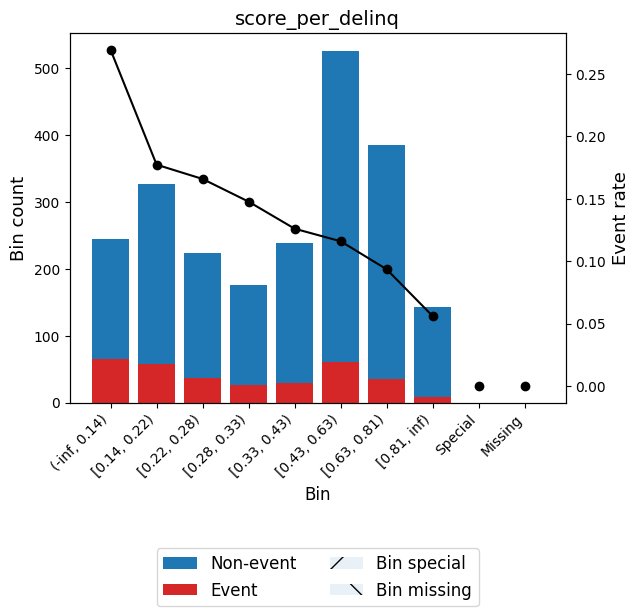

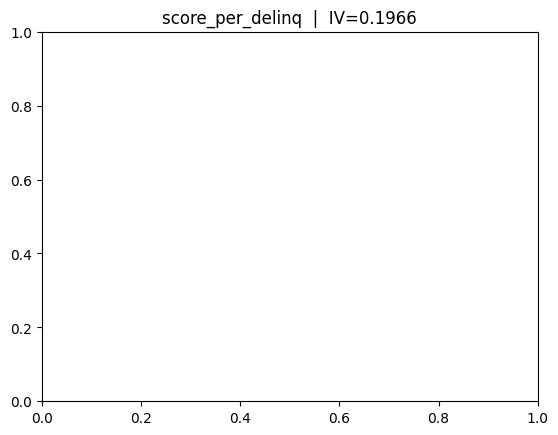

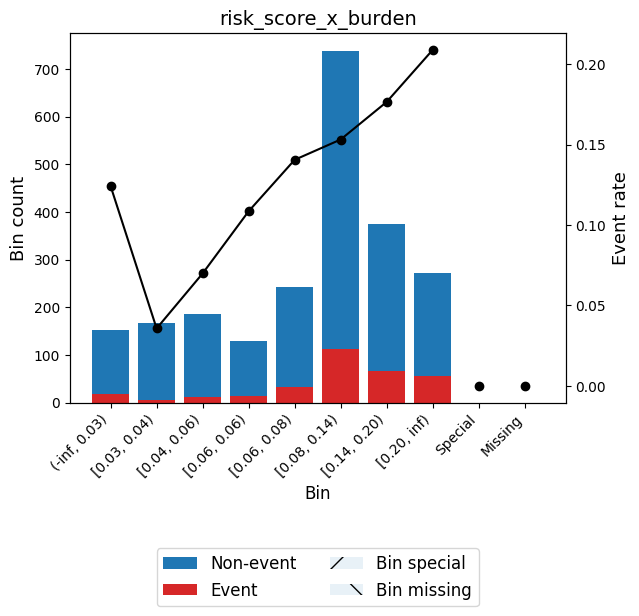

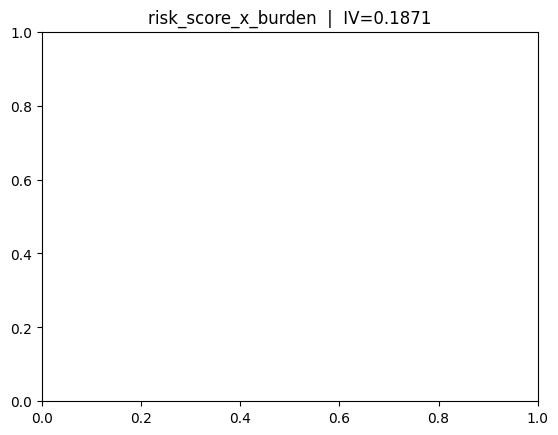

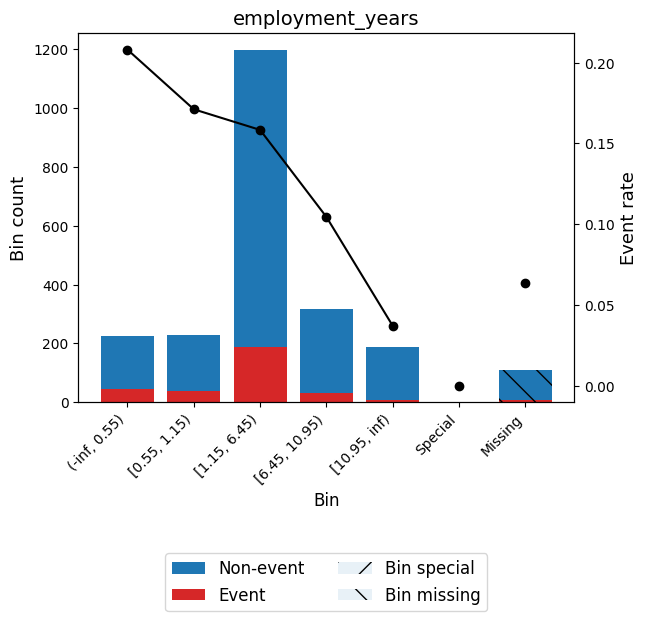

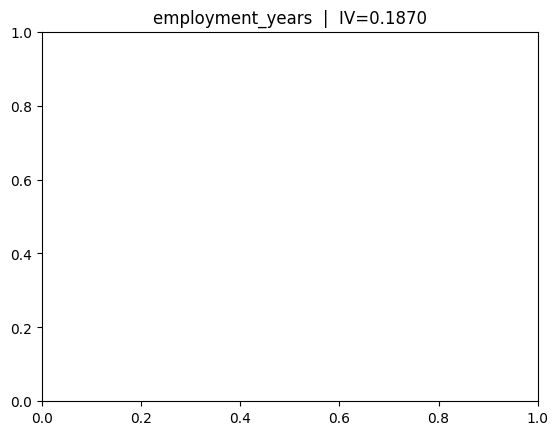

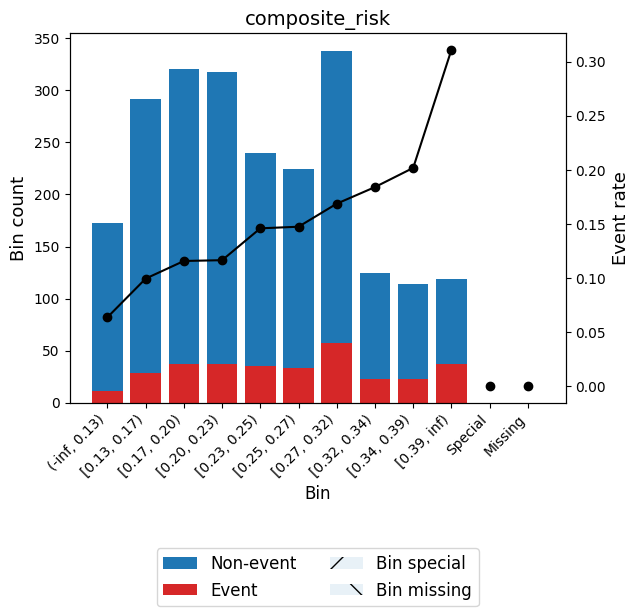

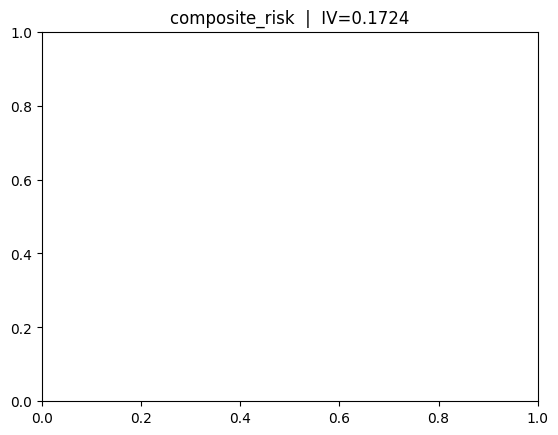

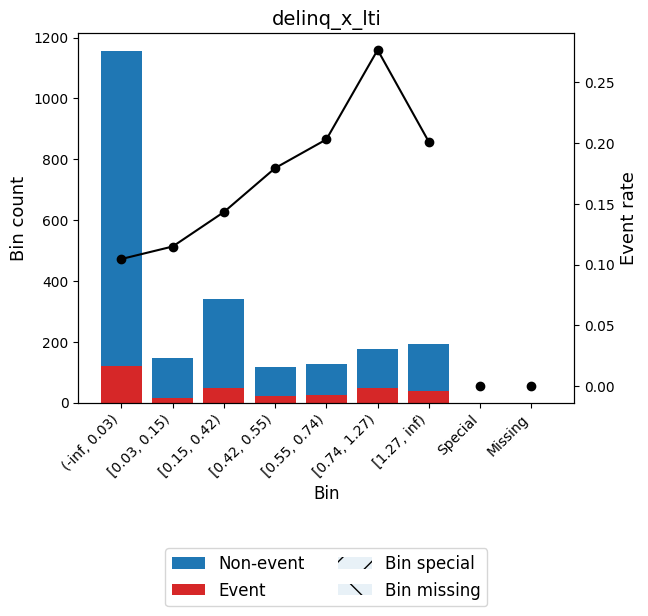

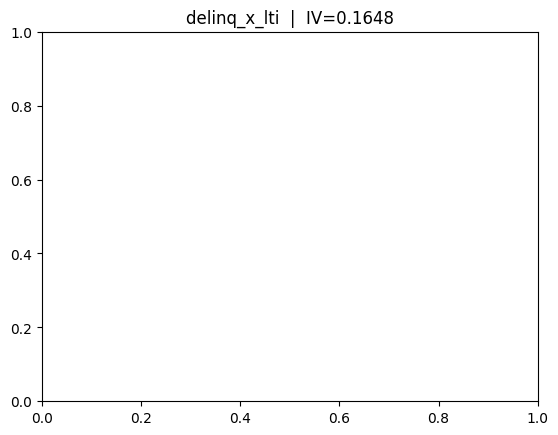

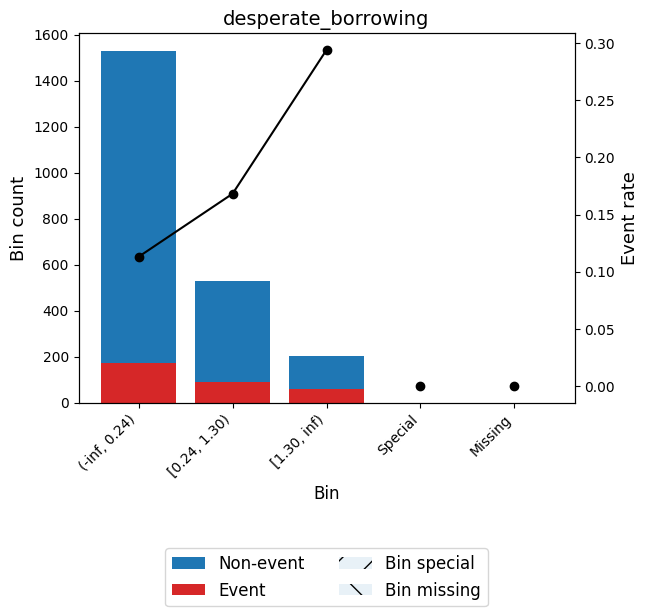

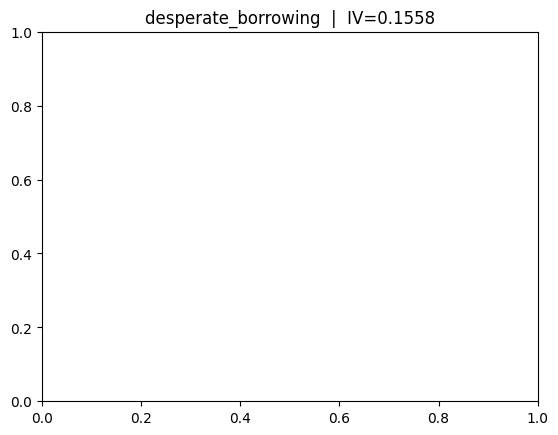

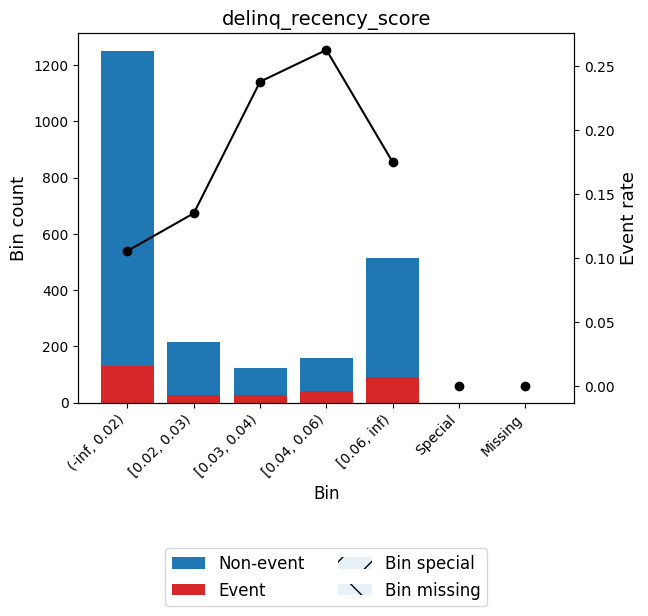

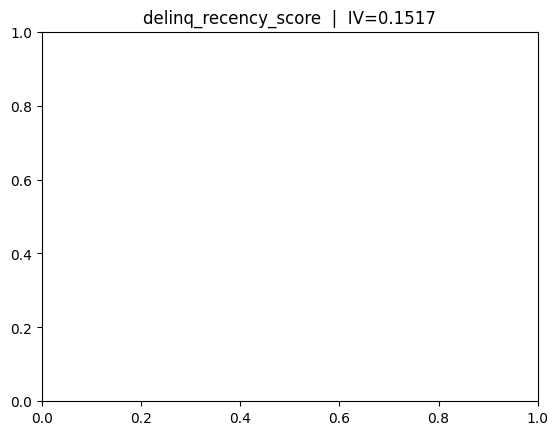

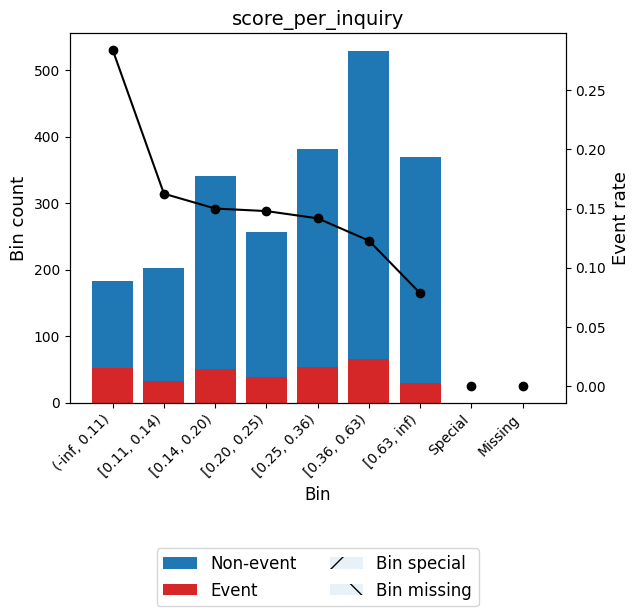

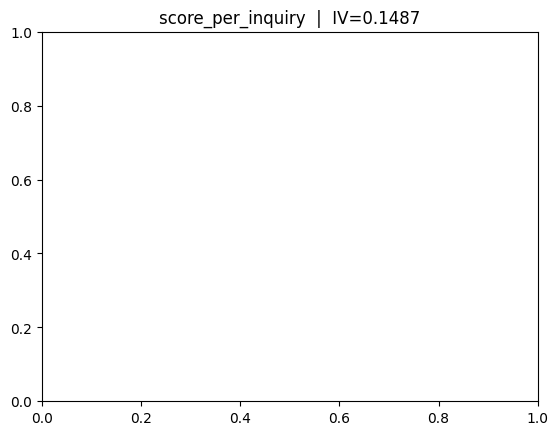

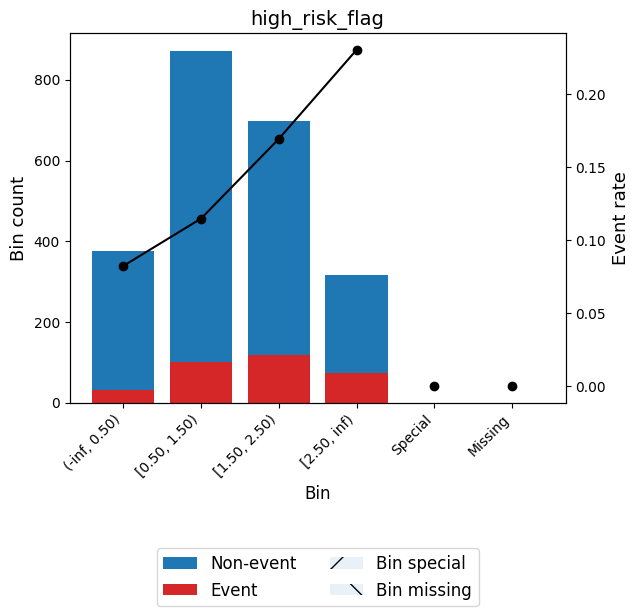

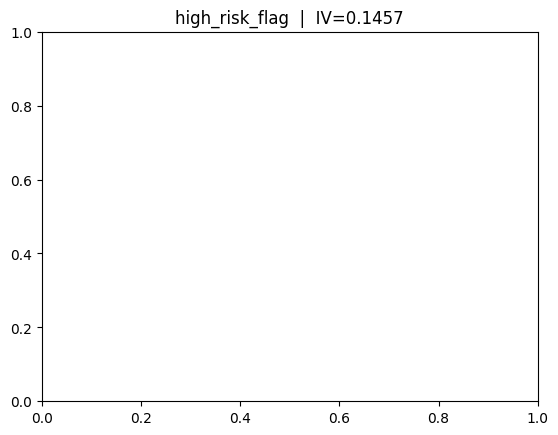

In [ ]:
for feature in final_features:
    build = binning_process_final.get_binned_variable(feature)
    build.binning_table.build()
    build.binning_table.plot(metric='event_rate', show_bin_labels=True)
    plt.title(f"{feature}  |  IV={iv_map.get(feature, 0):.4f}")
    plt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning,   module='sklearn')

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) - 1

def objective(trial):
    C = trial.suggest_float('C', 1e-4, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'  # supports both l1 and l2

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_woe, y_train)

    train_gini = gini(y_train, model.predict_proba(X_train_woe)[:, 1])
    val_gini   = gini(y_val,   model.predict_proba(X_val_woe)[:, 1])

    # Penalise overfitting — gap between train and val gini
    overfit_penalty = max(0, train_gini - val_gini - 0.05)  # allow up to 5% gap

    trial.set_user_attr('train_gini', round(train_gini, 4))
    trial.set_user_attr('val_gini',   round(val_gini, 4))

    return val_gini - overfit_penalty

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# -------------------------
# Best trial summary
# -------------------------
best = study.best_trial
print(f"Best params     : {best.params}")
print(f"Train Gini      : {best.user_attrs['train_gini']}")
print(f"Val Gini        : {best.user_attrs['val_gini']}")
print(f"Overfit gap     : {round(best.user_attrs['train_gini'] - best.user_attrs['val_gini'], 4)}")

# -------------------------
# Refit best model & evaluate on test
# -------------------------
best_model = LogisticRegression(
    **best.params,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)
best_model.fit(X_train_woe, y_train)

train_gini = gini(y_train, best_model.predict_proba(X_train_woe)[:, 1])
val_gini   = gini(y_val,   best_model.predict_proba(X_val_woe)[:, 1])
test_gini  = gini(y_test,  best_model.predict_proba(X_test_woe)[:, 1])

print(f"\n--- Final Evaluation ---")
print(f"Train Gini : {train_gini:.4f}")
print(f"Val Gini   : {val_gini:.4f}")
print(f"Test Gini  : {test_gini:.4f}")
print(f"Train-Test gap : {round(train_gini - test_gini, 4)}")

Best params     : {'C': 0.00010028639264201793, 'penalty': 'l2'}
Train Gini      : 0.416
Val Gini        : 0.208
Overfit gap     : 0.208

--- Final Evaluation ---
Train Gini : 0.4160
Val Gini   : 0.2080
Test Gini  : 0.4092
Train-Test gap : 0.0068


In [ ]:
from scipy.stats import ks_2samp
import numpy as np

def find_ks_threshold(y_true, y_proba):
    thresholds = np.linspace(0, 1, 200)
    ks_scores  = []

    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        tp_rate = y_true[y_proba >= t].mean() if (y_proba >= t).sum() > 0 else 0
        fp_rate = (1 - y_true)[y_proba >= t].mean() if (y_proba >= t).sum() > 0 else 0
        ks_scores.append(abs(tp_rate - fp_rate))

    # Proper KS — separation between default and non-default score distributions
    pos_scores = y_proba[y_true == 1]
    neg_scores = y_proba[y_true == 0]
    ks_stat, _ = ks_2samp(pos_scores, neg_scores)

    # Find threshold at max KS
    thresholds2  = np.sort(y_proba)
    tpr_list, fpr_list = [], []
    for t in thresholds2:
        tp = ((y_proba >= t) & (y_true == 1)).sum()
        fn = ((y_proba <  t) & (y_true == 1)).sum()
        fp = ((y_proba >= t) & (y_true == 0)).sum()
        tn = ((y_proba <  t) & (y_true == 0)).sum()
        tpr_list.append(tp / (tp + fn + 1e-9))
        fpr_list.append(fp / (fp + tn + 1e-9))

    ks_vals    = np.abs(np.array(tpr_list) - np.array(fpr_list))
    best_idx   = np.argmax(ks_vals)
    best_thresh = thresholds2[best_idx]
    best_ks     = ks_vals[best_idx]

    return best_thresh, best_ks

# -------------------------
# Find optimal threshold on val set
# -------------------------
val_proba  = best_model.predict_proba(X_val_woe)[:, 1]
opt_thresh, opt_ks = find_ks_threshold(y_val, val_proba)

print(f"Optimal KS threshold (val) : {opt_thresh:.4f}")
print(f"KS statistic               : {opt_ks:.4f}")

# -------------------------
# Evaluate on test & OOT using KS threshold
# -------------------------
from sklearn.metrics import f1_score, classification_report

for name, y_true, y_proba in [
    ('Val',  y_val,          val_proba),
    ('Test', y_test,         best_model.predict_proba(X_test_woe)[:, 1])
]:
    y_pred = (y_proba >= opt_thresh).astype(int)
    print(f"\n--- {name} (threshold={opt_thresh:.4f}) ---")
    print(f"Gini : {gini(y_true, y_proba):.4f}")
    print(f"F1   : {f1_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, target_names=['No Default', 'Default']))

Optimal KS threshold (val) : 0.4804
KS statistic               : 0.2237

--- Val (threshold=0.4804) ---
Gini : 0.2080
F1   : 0.3165
              precision    recall  f1-score   support

  No Default       0.90      0.71      0.79       257
     Default       0.23      0.51      0.32        43

    accuracy                           0.68       300
   macro avg       0.56      0.61      0.56       300
weighted avg       0.80      0.68      0.73       300


--- Test (threshold=0.4804) ---
Gini : 0.4092
F1   : 0.4000
              precision    recall  f1-score   support

  No Default       0.93      0.71      0.81       258
     Default       0.28      0.69      0.40        42

    accuracy                           0.71       300
   macro avg       0.61      0.70      0.60       300
weighted avg       0.84      0.71      0.75       300


--- OOT (threshold=0.4804) ---
Gini : 0.2635
F1   : 0.2920
              precision    recall  f1-score   support

  No Default       0.92      0.31     

In [ ]:
oot=pd.read_csv("/content/credit_test_with_default.csv")
print(oot.shape)
oot.head()

(1000, 15)


,age,income,loan_amount,loan_term,credit_score,num_credit_lines,num_delinquencies,employment_years,debt_to_income,home_ownership,loan_purpose,num_inquiries,savings_balance,months_last_delinq,default
0,22,29355,9318,36,545,2,1,15.2,0.222,RENT,PERSONAL,0,3783.0,29.0,0
1,56,130825,6513,24,658,12,0,7.9,0.243,MORTGAGE,PERSONAL,0,1685.0,NaN,0
2,61,72413,12846,24,674,10,0,1.8,0.326,OWN,PERSONAL,1,1808.0,NaN,0
3,30,106765,13909,48,715,6,1,11.4,0.342,MORTGAGE,MEDICAL,1,1022.0,65.0,0
4,61,44529,8754,24,724,1,2,0.8,0.324,MORTGAGE,DEBT_CONSOLIDATION,1,19126.0,4.0,0


In [ ]:
best_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.00010028434912813882
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :

In [ ]:
binning_process_final

,variable_names,"['risk_score_x_burden', 'composite_risk', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,10
,min_bin_size,0.05
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,None
,fixed_variables,None


In [ ]:
binning_process_final.variable_names

['risk_score_x_burden',
 'composite_risk',
 'score_per_delinq',
 'high_risk_flag',
 'score_per_inquiry',
 'employment_years',
 'loan_amount',
 'delinq_recency_score',
 'delinq_x_lti',
 'delinq_x_inquiry',
 'renter_x_lti',
 'age',
 'renter_x_dti']

In [ ]:
# -------------------------
# 1. Feature engineering on OOT
# -------------------------
oot_feat = make_raw_credit_features(oot)

# -------------------------
# 2. Keep only final selected features
# -------------------------
oot_feat = oot_feat[binning_process_final.variable_names]

# -------------------------
# 3. Transform via already-fitted binning process (no refit — avoids leakage)
# -------------------------
oot_woe = binning_process_final.transform(oot_feat, metric='woe')

# -------------------------
# 4. Predict
# -------------------------
oot_proba = best_model.predict_proba(oot_woe)[:, 1]
oot_gini  = gini(oot['default'], oot_proba)

In [ ]:
oot_gini

0.3655470469010009

In [ ]:
from sklearn.metrics import f1_score, classification_report

# Use 0.5 threshold or optimise on val
oot_pred = (oot_proba >= opt_thresh).astype(int)

f1  = f1_score(oot['default'], oot_pred)
print(f"OOT Gini : {oot_gini:.4f}")
print(f"OOT F1   : {f1:.4f}")
print()
print(classification_report(oot['default'], oot_pred, target_names=['No Default', 'Default']))

OOT Gini : 0.3655
OOT F1   : 0.3242

              precision    recall  f1-score   support

  No Default       0.89      0.71      0.79       851
     Default       0.24      0.52      0.32       149

    accuracy                           0.68      1000
   macro avg       0.56      0.61      0.56      1000
weighted avg       0.80      0.68      0.72      1000



In [ ]:
def preprocess_data(df, training_medians):
    df = df.copy()

    # -------------------------
    # Impute missing values
    # -------------------------
    df['months_last_delinq'] = df['months_last_delinq'].fillna(0)
    df['employment_years']   = df['employment_years'].fillna(training_medians['employment_years'])
    df['savings_balance']    = df['savings_balance'].fillna(training_medians['savings_balance'])
    df = df.fillna(0)

    # -------------------------
    # Engineered features
    # -------------------------
    df['loan_to_income'] = np.where(
        df['income'] > 0,
        df['loan_amount'] / df['income'],
        0
    )
    df['payment_to_income'] = np.where(
        (df['loan_term'] > 0) & (df['income'] > 0),
        (df['loan_amount'] / df['loan_term']) / df['income'] * 12,
        0
    )
    df['credit_utilization_proxy'] = np.where(
        df['credit_score'] > 0,
        df['num_credit_lines'] / (df['credit_score'] / 100),
        0
    )
    df['delinq_flag']       = (df['num_delinquencies'] >= 1).astype(int)
    df['high_inquiry_flag'] = (df['num_inquiries'] >= 3).astype(int)

    # Clean up any inf/nan from division
    for c in ['loan_to_income', 'payment_to_income', 'credit_utilization_proxy']:
        df[c] = df[c].replace([np.inf, -np.inf], 0).fillna(0)

    # -------------------------
    # Categorical encoding
    # -------------------------
    df = pd.get_dummies(df, columns=['home_ownership', 'loan_purpose'],
                        drop_first=True, dtype=int)
    return df


def align_columns(df, training_columns):
    for c in training_columns:
        if c not in df.columns:
            df[c] = 0
    return df[training_columns]


def compute_woe_transform(df, woe_mappings):
    df = df.copy()
    for feature, mapping in woe_mappings.items():
        edges    = mapping['edges']
        woe_vals = mapping['woe_values']
        col      = feature + '_woe'
        df[col]  = pd.cut(
            df[feature],
            bins=edges,
            labels=woe_vals,
            include_lowest=True,
            right=True
        ).astype(float)
        df[col] = df[col].fillna(0)
    return df


def compute_scorecard(y_true, y_pred, y_proba, cutoff, n_predictors,
                      profit_good=10, cost_default=-70, cost_reject=-2):
    from sklearn.metrics import (
        confusion_matrix, roc_auc_score, roc_curve,
        accuracy_score, precision_score, recall_score, f1_score
    )

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    auc_val        = roc_auc_score(y_true, y_proba)
    fpr, tpr, _    = roc_curve(y_true, y_proba)
    ks             = float((tpr - fpr).max())
    gini_val       = 2 * auc_val - 1
    profit         = int(tn) * profit_good + int(fn) * cost_default + (int(tp) + int(fp)) * cost_reject
    app_rate       = (int(tn) + int(fn)) / len(y_true) * 100
    def_rate       = int(fn) / max(int(tn) + int(fn), 1) * 100

    return dict(
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
        auc=auc_val, ks=ks, gini=gini_val,
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred, zero_division=0),
        specificity=tn / max(tn + fp, 1),
        f1=f1_score(y_true, y_pred, zero_division=0),
        profit=profit,
        profit_per_loan=profit / len(y_true),
        approval_rate=app_rate,
        default_rate=def_rate,
        n_predictors=n_predictors,
        cutoff=cutoff
    )


def print_competition_scorecard(sc, participant_name=''):
    w = 64

    def row(label, value): print(f'║ {label:<30} ║ {value:<29} ║')
    def div():              print('╠' + '═' * 32 + '╬' + '═' * 31 + '╣')

    print('╔' + '═' * w + '╗')
    print(f'║ {f" COMPETITION SCORECARD — {participant_name}":<{w-2}} ║')
    div()
    row('PRIZE 1 — BEST F1',         '')
    row('  F1 Score',                 f"{sc['f1']:.4f}")
    row('  Recall',                   f"{sc['recall']:.4f}")
    row('  Precision',                f"{sc['precision']:.4f}")
    row('  Number of Predictors',     str(sc['n_predictors']))
    div()
    row('PRIZE 2 — BEST AUC',         '')
    row('  AUC',                      f"{sc['auc']:.4f}")
    row('  KS Statistic',             f"{sc['ks']:.4f}")
    row('  Gini Coefficient',         f"{sc['gini']:.4f}")
    div()
    row('PRIZE 3 — HIGHEST PROFIT',   '')
    row('  Total Profit',             str(sc['profit']))
    row('  Approval Rate',            f"{sc['approval_rate']:.1f}%")
    row('  Profit per Loan',          f"{sc['profit_per_loan']:.2f}")
    div()
    row('PRIZE 4 — LOWEST DEFAULT',   '')
    row('  Default Rate (Approved)',   f"{sc['default_rate']:.1f}%")
    row('  Approval Rate',            f"{sc['approval_rate']:.1f}%")
    row('  Defaults among Approved',  str(sc['fn']))
    div()
    row('OTHER METRICS',              '')
    row('  Accuracy',                 f"{sc['accuracy']:.4f}")
    row('  Specificity',              f"{sc['specificity']:.4f}")
    row('  Chosen Cutoff',            f"{sc['cutoff']:.4f}")
    print('╚' + '═' * 32 + '╩' + '═' * 31 + '╝')


def score_loans(filepath, model, scaler, best_cutoff, woe_mappings,
                training_columns, training_medians,
                has_target=True, participant_name=''):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import roc_curve, confusion_matrix

    df_raw = pd.read_csv(filepath)
    y_true = None

    if has_target:
        y_true = df_raw['default'].values
        df_raw = df_raw.drop(columns=['default'])

    # Preprocess → WoE → align
    df = preprocess_data(df_raw, training_medians)
    df = compute_woe_transform(df, woe_mappings)
    df = align_columns(df, training_columns)

    # Scale & predict
    X      = scaler.transform(df.values.astype(float))
    X      = np.where(np.isnan(X) | np.isinf(X), 0, X)
    y_prob = model.predict_proba(X)[:, 1]

    assert not np.any(np.isnan(y_prob)), 'NaN found in predicted probabilities'

    y_pred = (y_prob >= best_cutoff).astype(int)
    n_pred = int((model.coef_[0] != 0).sum()) if hasattr(model, 'coef_') else len(training_columns)

    # Output df
    df_out = df_raw.copy()
    df_out['default_probability'] = y_prob
    df_out['predicted_default']   = y_pred
    df_out['risk_tier']           = pd.cut(
        y_prob,
        bins=[-0.001, 0.2, 0.4, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    if has_target and y_true is not None:
        sc = compute_scorecard(y_true, y_pred, y_prob, best_cutoff, n_pred)
        print_competition_scorecard(sc, participant_name)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0].plot(fpr, tpr, label=f'AUC={sc["auc"]:.3f}')
        axes[0].plot([0, 1], [0, 1], '--')
        axes[0].set_title('ROC Curve')
        axes[0].legend()

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], cmap='Blues')
        axes[1].set_title('Confusion Matrix')

        for cls, lbl in [(0, 'Good'), (1, 'Default')]:
            axes[2].hist(y_prob[y_true == cls], bins=30, alpha=0.5, label=lbl)
        axes[2].axvline(best_cutoff, color='red', linestyle='--', label='Cutoff')
        axes[2].set_title('Score Distribution')
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    else:
        print(f"Score distribution : mean={y_prob.mean():.3f}  std={y_prob.std():.3f}")
        print(f"Approval rate at cutoff {best_cutoff:.3f} : {(y_pred == 0).mean() * 100:.1f}%")
        print("Risk tiers:")
        print(df_out['risk_tier'].value_counts())

        plt.hist(y_prob, bins=40, edgecolor='k')
        plt.axvline(best_cutoff, color='red', linestyle='--', label='Cutoff')
        plt.title('Predicted Default Probability')
        plt.legend()
        plt.show()

    return df_out

print('All scoring functions defined successfully.')

All scoring functions defined successfully.


In [ ]:
from sklearn.metrics import roc_curve

# -------------------------
# 1. Feature engineering
# -------------------------
oot_feat = make_raw_credit_features(oot)

# -------------------------
# 2. Keep only features binning was fitted on
# -------------------------
oot_feat = oot_feat[binning_process_final.variable_names]

# -------------------------
# 3. WoE transform
# -------------------------
oot_woe = binning_process_final.transform(oot_feat, metric='woe')

# -------------------------
# 4. Predict
# -------------------------
y_true  = oot['default'].values
y_prob  = best_model.predict_proba(oot_woe)[:, 1]

# -------------------------
# 5. KS optimal threshold from val
# -------------------------
val_prob       = best_model.predict_proba(X_val_woe)[:, 1]
fpr, tpr, thr  = roc_curve(y_val, val_prob)
ks_idx         = np.argmax(tpr - fpr)
best_cutoff    = thr[ks_idx]
print(f"KS optimal threshold : {best_cutoff:.4f}")

# -------------------------
# 6. Score
# -------------------------
y_pred  = (y_prob >= best_cutoff).astype(int)
n_pred  = int((best_model.coef_[0] != 0).sum())

sc = compute_scorecard(y_true, y_pred, y_prob, best_cutoff, n_pred)
print_competition_scorecard(sc, participant_name='Pathorn Kitisupavatana')

KS optimal threshold : 0.4804
╔════════════════════════════════════════════════════════════════╗
║  COMPETITION SCORECARD — Pathorn Kitisupavatana                ║
╠════════════════════════════════╬═══════════════════════════════╣
║ PRIZE 1 — BEST F1              ║                               ║
║   F1 Score                     ║ 0.3242                        ║
║   Recall                       ║ 0.5168                        ║
║   Precision                    ║ 0.2362                        ║
║   Number of Predictors         ║ 13                            ║
╠════════════════════════════════╬═══════════════════════════════╣
║ PRIZE 2 — BEST AUC             ║                               ║
║   AUC                          ║ 0.6828                        ║
║   KS Statistic                 ║ 0.2832                        ║
║   Gini Coefficient             ║ 0.3655                        ║
╠════════════════════════════════╬═══════════════════════════════╣
║ PRIZE 3 — HIGHEST PROFIT      

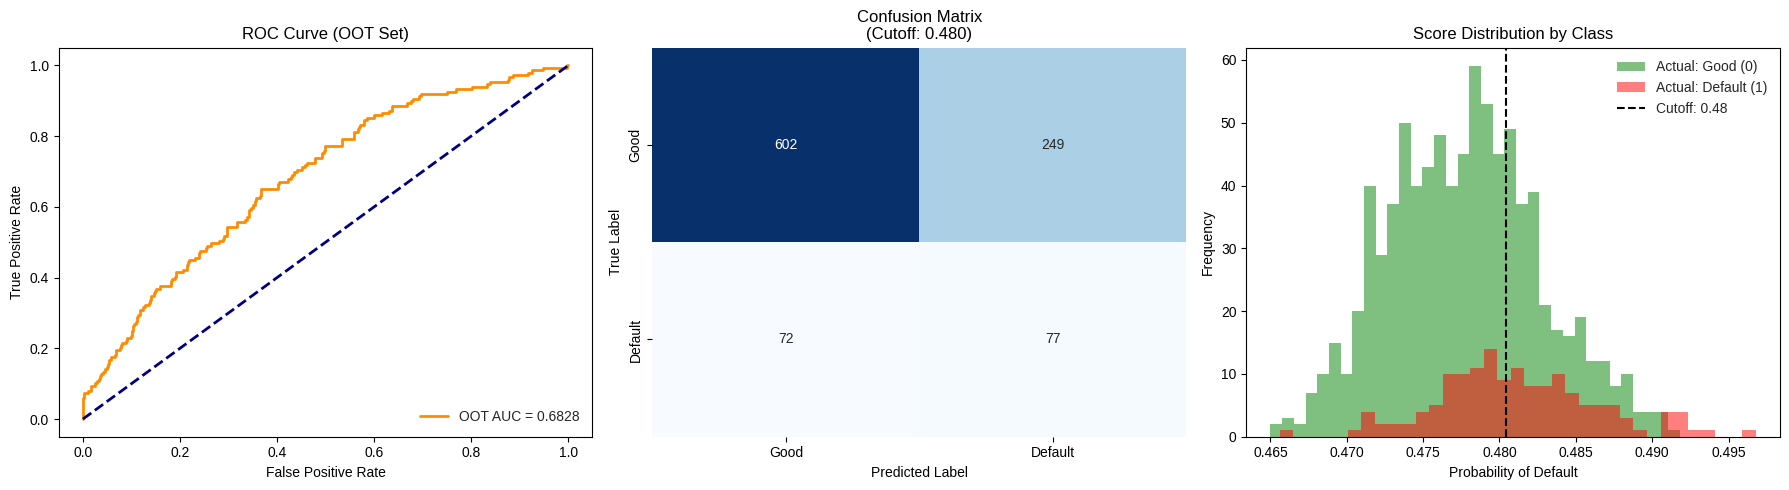

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# 1. Create the figure layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.style.use('seaborn-v0_8-whitegrid') # Optional: cleaner look

# --- Plot 1: ROC Curve ---
fpr_oot, tpr_oot, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr_oot, tpr_oot, color='darkorange', lw=2, label=f'OOT AUC = {sc["auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (OOT Set)')
axes[0].legend(loc="lower right")

# --- Plot 2: Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title(f'Confusion Matrix\n(Cutoff: {best_cutoff:.3f})')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
# Standard labeling for credit: 0=Good, 1=Default
axes[1].set_xticklabels(['Good', 'Default'])
axes[1].set_yticklabels(['Good', 'Default'])

# --- Plot 3: Score Distribution & Separation ---
# This shows how well the model separates the two classes
axes[2].hist(y_prob[y_true == 0], bins=35, alpha=0.5, label='Actual: Good (0)', color='green')
axes[2].hist(y_prob[y_true == 1], bins=35, alpha=0.5, label='Actual: Default (1)', color='red')
axes[2].axvline(best_cutoff, color='black', linestyle='--', label=f'Cutoff: {best_cutoff:.2f}')
axes[2].set_title('Score Distribution by Class')
axes[2].set_xlabel('Probability of Default')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()